### Fetching Data from ERA5, Forecasts, and AMDAR

In [59]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import os
import dask
import pandas as pd

In [2]:
# paths
DATA_BASE = "/mnt/hdd/jetstream/data/development"

CEDA = "/ceda/july_2019/"
ERA5 = "/era5/july2019/reanalysis_2019_07"
ECMWF = "/ecmwf/july_2019/"

ecmwf_path = os.path.join(DATA_BASE, ECMWF)
era5_path = os.path.join(DATA_BASE, ERA5)
ceda_path = os.path.join(DATA_BASE, CEDA)

In [314]:
g = 9.80665

ERA5 reanalysis

In [10]:
era5_ds = xr.open_mfdataset(f"{DATA_BASE}{era5_path}/pressure/2019/07/*.nc", combine="by_coords")

In [35]:
era5_ds

<xarray.Dataset> Size: 46GB
Dimensions:         (valid_time: 744, pressure_level: 5, latitude: 721,
                     longitude: 1440)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 6kB 2019-07-01 ... 2019-07-31...
    expver          (valid_time) <U4 12kB dask.array<chunksize=(24,), meta=np.ndarray>
  * pressure_level  (pressure_level) float64 40B 700.0 500.0 300.0 250.0 200.0
  * latitude        (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude       (longitude) float64 12kB 0.0 0.25 0.5 ... 359.2 359.5 359.8
    number          int64 8B 0
Data variables:
    z               (valid_time, pressure_level, latitude, longitude) float32 15GB dask.array<chunksize=(8, 1, 241, 480), meta=np.ndarray>
    u               (valid_time, pressure_level, latitude, longitude) float32 15GB dask.array<chunksize=(8, 1, 241, 480), meta=np.ndarray>
    v               (valid_time, pressure_level, latitude, longitude) float32 15GB dask.array<chunksize=(8, 1, 241, 480), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-22T04:58 GRIB to CDM+CF via cfgrib-0.9.1...

In [ ]:
def plot_quiver(lat, lon, u, v, reduce_factor=5, show_plot=True):
    # reduce to every 5th point for better visualization
    lat = lat[::reduce_factor]
    lon = lon[::reduce_factor]
    u = u[::reduce_factor, ::reduce_factor]
    v = v[::reduce_factor, ::reduce_factor]

    plt.figure(figsize=(10, 6))
    plt.quiver(lon, lat, u, v)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    if show_plot:
        plt.show()
    else:
        return plt.gca()

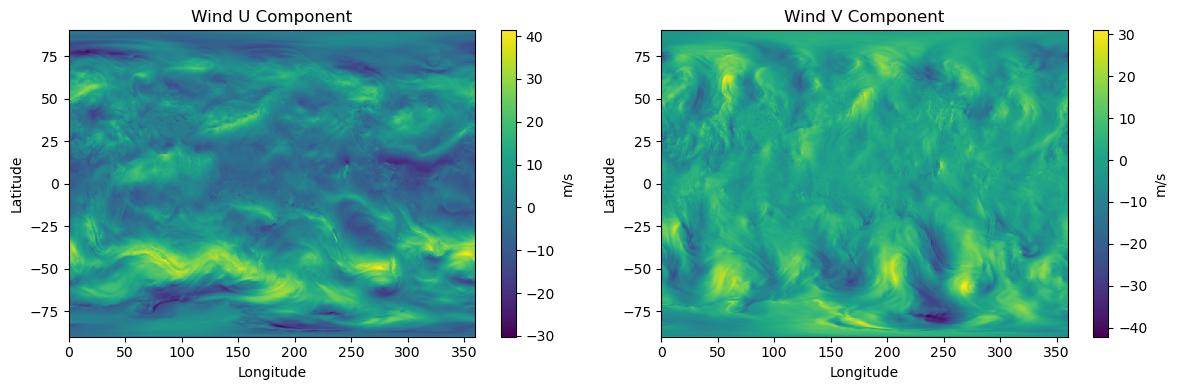

In [31]:
# plot wind u and wind v in two subplots
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.title("Wind U Component")
plt.pcolormesh(era5_ds.longitude, era5_ds.latitude, era5_ds.isel(valid_time=0, pressure_level=0)['u'], shading='auto')
plt.colorbar(label='m/s')
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.subplot(1, 2, 2)
plt.title("Wind V Component")
plt.pcolormesh(era5_ds.longitude, era5_ds.latitude, era5_ds.isel(valid_time=0, pressure_level=0)['v'], shading='auto')
plt.colorbar(label='m/s')
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

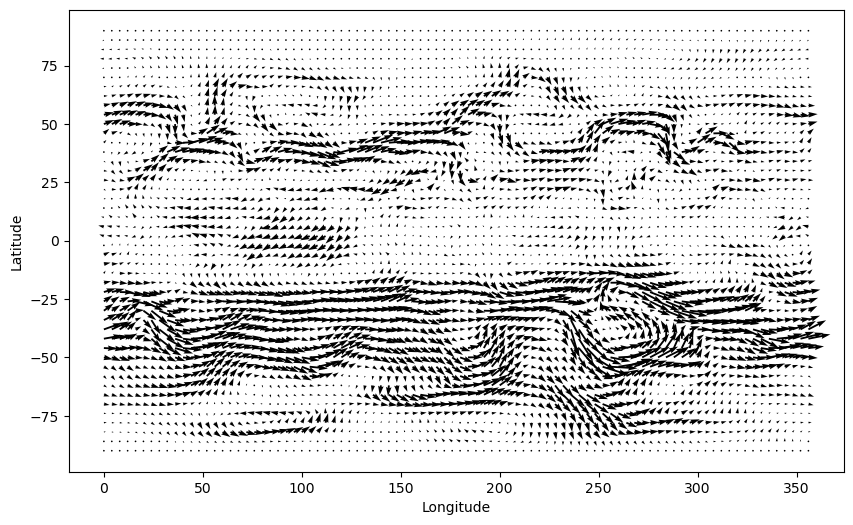

In [57]:
plot_quiver(
    era5_ds.latitude.values,
    era5_ds.longitude.values,
    era5_ds.sel(valid_time='2019-07-01T00:00:00.000000000').sel(pressure_level=200)['u'].values,
    era5_ds.sel(valid_time='2019-07-01T00:00:00.000000000').sel(pressure_level=200)['v'].values,
    reduce_factor=16
)

ECMWF Forecasts

In [33]:
ecmwf_ds = xr.open_dataset(f"{DATA_BASE}{ecmwf_path}/ecmwf_forecast.nc")

In [ ]:
ecmwf_ds

<xarray.Dataset> Size: 2GB
Dimensions:     (time: 125, latitude: 361, longitude: 720)
Coordinates:
  * time        (time) datetime64[ns] 1kB 2019-07-01 ... 2019-08-01
  * latitude    (latitude) float64 3kB -90.0 -89.5 -89.0 ... 89.0 89.5 90.0
  * longitude   (longitude) float64 6kB 0.0 0.5 1.0 1.5 ... 358.5 359.0 359.5
Data variables: (12/15)
    UGRD_200mb  (time, latitude, longitude) float32 130MB ...
    VGRD_200mb  (time, latitude, longitude) float32 130MB ...
    HGT_200mb   (time, latitude, longitude) float32 130MB ...
    UGRD_250mb  (time, latitude, longitude) float32 130MB ...
    VGRD_250mb  (time, latitude, longitude) float32 130MB ...
    HGT_250mb   (time, latitude, longitude) float32 130MB ...
    ...          ...
    UGRD_500mb  (time, latitude, longitude) float32 130MB ...
    VGRD_500mb  (time, latitude, longitude) float32 130MB ...
    HGT_500mb   (time, latitude, longitude) float32 130MB ...
    UGRD_700mb  (time, latitude, longitude) float32 130MB ...
    VGRD_700mb  (time, latitude, longitude) float32 130MB ...
    HGT_700mb   (time, latitude, longitude) float32 130MB ...
Attributes:
    Conventions:          COARDS
    History:              created by wgrib2
    GRIB2_grid_template:  0

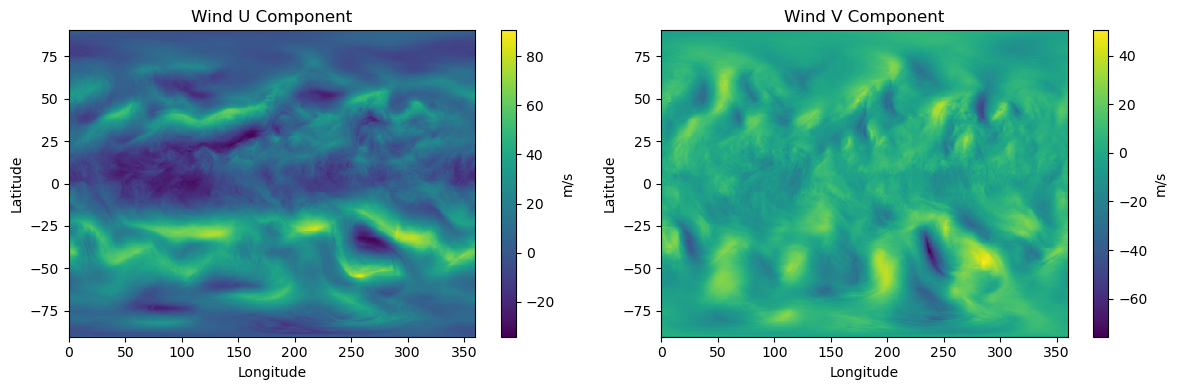

In [58]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.title("Wind U Component")
plt.pcolormesh(ecmwf_ds.longitude, ecmwf_ds.latitude, ecmwf_ds.sel(time='2019-07-01T00:00:00.000000000')['UGRD_200mb'], shading='auto')
plt.colorbar(label='m/s')
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.subplot(1, 2, 2)
plt.title("Wind V Component")
plt.pcolormesh(ecmwf_ds.longitude, ecmwf_ds.latitude, ecmwf_ds.sel(time='2019-07-01T00:00:00.000000000')['VGRD_200mb'], shading='auto')
plt.colorbar(label='m/s')
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

In [56]:
ecmwf_ds.sel(time='2019-07-01T00:00:00.000000000')['time']

<xarray.DataArray 'time' ()> Size: 8B
array('2019-07-01T00:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 8B 2019-07-01
Attributes:
    long_name:                   verification time generated by wgrib2 functi...
    reference_time:              1561939200.0
    reference_time_type:         0
    reference_date:              2019.07.01 00:00:00 UTC
    reference_time_description:  kind of product unclear, reference date is v...
    time_step_setting:           auto
    time_step:                   21600.0

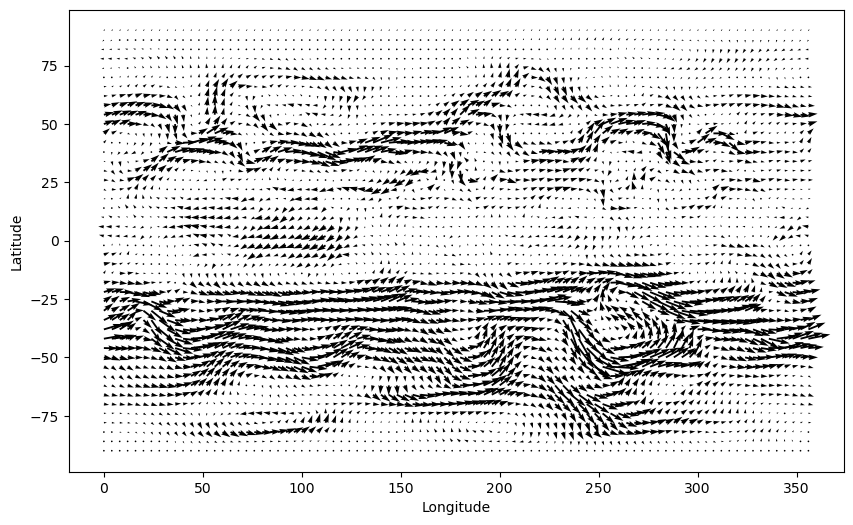

In [51]:
plot_quiver(
    ecmwf_ds.latitude.values,
    ecmwf_ds.longitude.values,  
    ecmwf_ds.isel(time=0)['UGRD_200mb'].values,
    ecmwf_ds.isel(time=0)['VGRD_200mb'].values,
    reduce_factor=8
)

Aircraft Observations

In [66]:
f"{DATA_BASE}{CEDA}data.ceda.ac.uk/badc/ukmo-metdb/data/amdars/2019/07/ukmo-metdb_amdars_20190701.csv"

'/mnt/hdd/jetstream/data/development/ceda/july_2019/data.ceda.ac.uk/badc/ukmo-metdb/data/amdars/2019/07/ukmo-metdb_amdars_20190701.csv'

In [75]:
aircraft_df = pd.read_csv(f"{DATA_BASE}{CEDA}data.ceda.ac.uk/badc/ukmo-metdb/data/amdars/2019/07/ukmo-metdb_amdars_20190701.csv", skiprows=184, encoding_errors='ignore')

/tmp/ipykernel_2067/1331835301.py:1: DtypeWarning: Columns (0: 1) have mixed types. Specify dtype option on import or set low_memory=False.
  aircraft_df = pd.read_csv(f"{DATA_BASE}{CEDA}data.ceda.ac.uk/badc/ukmo-metdb/data/amdars/2019/07/ukmo-metdb_amdars_20190701.csv", skiprows=184, encoding_errors='ignore')


In [76]:
aircraft_df.head()

,1,2,3,4,5,6,7,8,9,10,...,26,27,28,29,30,31,32,33,34,35
0,2019,7.0,1.0,0.0,0.0,-9999999.0,2019.0,7.0,1.0,0.0,...,21.6,-9999999.0,-9999999.0,-9999999.0,1.0,242.1,-9999999.0,-9999999.0,-9999999.000,-9999999.0
1,2019,7.0,1.0,0.0,0.0,-9999999.0,2019.0,7.0,1.0,0.0,...,29.8,-9999999.0,-9999999.0,-9999999.0,-9999999.0,214.0,-9999999.0,-9999999.0,0.000,-9999999.0
2,2019,7.0,1.0,0.0,0.0,-9999999.0,2019.0,7.0,1.0,0.0,...,17.5,-9999999.0,-9999999.0,-9999999.0,1.0,257.0,-9999999.0,-9999999.0,-9999999.000,-9999999.0
3,2019,7.0,1.0,0.0,0.0,-9999999.0,2019.0,7.0,1.0,0.0,...,12.9,-9999999.0,-9999999.0,-9999999.0,-9999999.0,262.7,-9999999.0,-9999999.0,0.000,-9999999.0
4,2019,7.0,1.0,0.0,0.0,-9999999.0,2019.0,7.0,1.0,0.0,...,8.7,-9999999.0,-9999999.0,-9999999.0,-9999999.0,276.2,-9999999.0,-9999999.0,0.004,-9999999.0


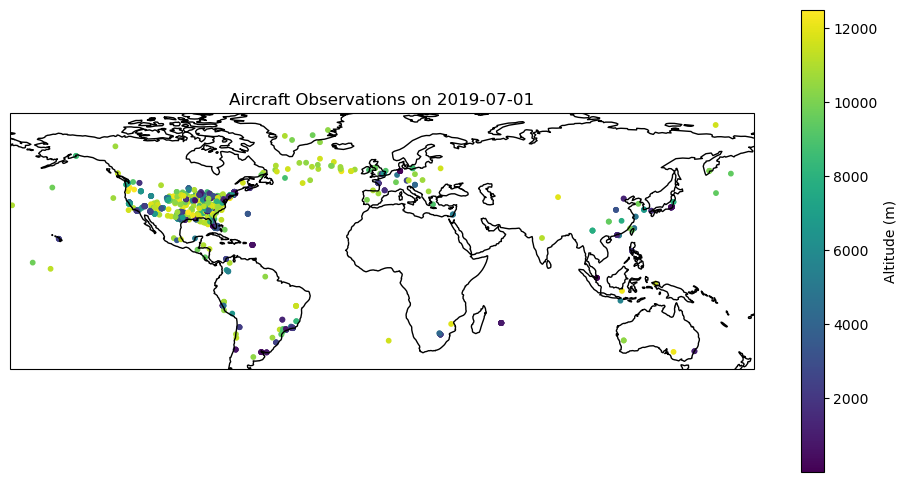

In [83]:
# plot the first 1000 rows of the aircraft data on a scatter plot of longitude vs latitude, colored by altitude.
# include a basemap of the world using cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature

data = aircraft_df[338000:339000][aircraft_df[338000:339000]['14'].between(-90, 90) & aircraft_df[338000:339000]['15'].between(-180, 180) & aircraft_df[338000:339000]['16'].between(0, 20000)]

plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE)
scatter = ax.scatter(data['15'], data['14'], c=data['16'], cmap='viridis', s=10, transform=ccrs.PlateCarree())
plt.colorbar(scatter, label='Altitude (m)')
plt.title('Aircraft Observations on 2019-07-01')
plt.show()

Aircraft data is quite biased to the united states.

Comparisons and EDA

In [71]:
# comparing ecmwf and era5 at 2019-07-01T00:00:00.000000000 at 200mb

ecmwf_compare = ecmwf_ds.sel(time='2019-07-01T00:00:00.000000000')[['UGRD_200mb', 'VGRD_200mb']]
era5_compare = era5_ds.sel(valid_time='2019-07-01T00:00:00.000000000').sel(pressure_level=200)[['u', 'v']]

# linear interpolation with xarray of ecmwf_ds to era5_ds grid
ecmwf_compare_regrid = ecmwf_compare.interp(latitude=era5_compare.latitude, longitude=era5_compare.longitude)

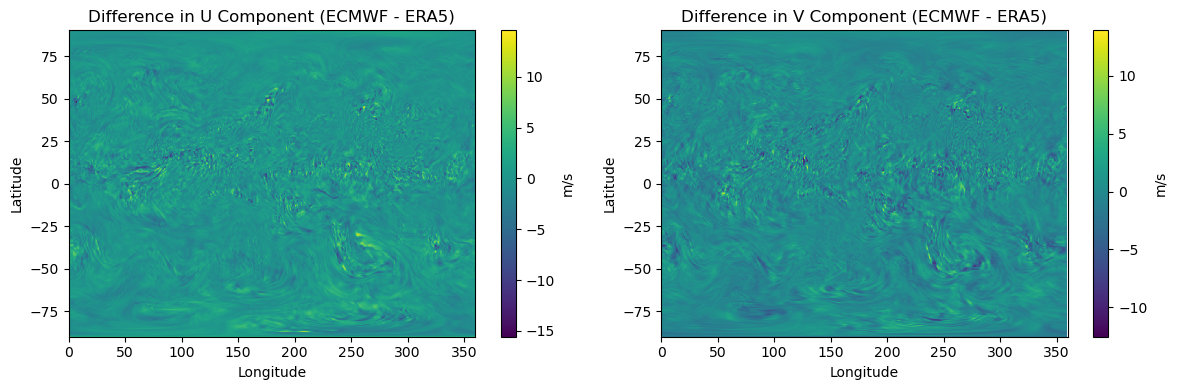

In [72]:
# plot the difference between ecmwf and era5 for u and v components
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.title("Difference in U Component (ECMWF - ERA5)")
plt.pcolormesh(era5_compare.longitude, era5_compare.latitude, ecmwf_compare_regrid['UGRD_200mb'] - era5_compare['u'], shading='auto')
plt.colorbar(label='m/s')
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.subplot(1, 2, 2)
plt.title("Difference in V Component (ECMWF - ERA5)")
plt.pcolormesh(era5_compare.longitude, era5_compare.latitude, ecmwf_compare_regrid['VGRD_200mb'] - era5_compare['v'], shading='auto')
plt.colorbar(label='m/s')
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

Find the mean of each component (important for normalization)

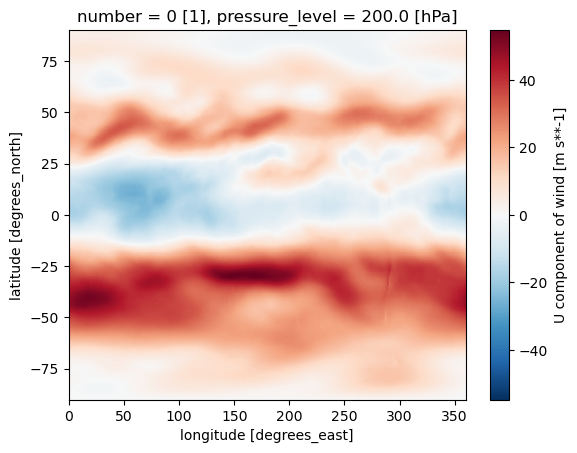

In [88]:
era5_ds.sel(pressure_level=200)['u'].mean(dim=['valid_time']).plot(label='ERA5 U')

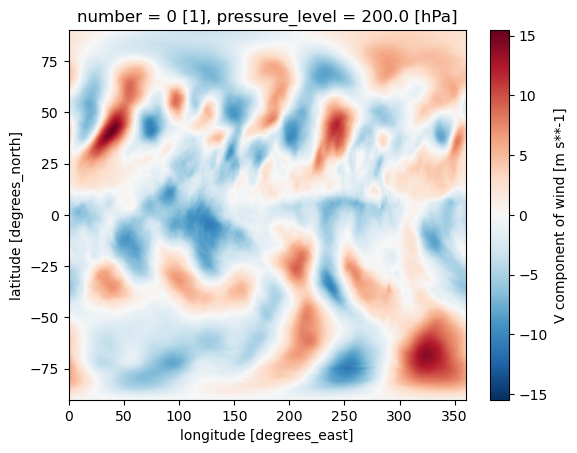

In [90]:
era5_ds.sel(pressure_level=200)['v'].mean(dim=['valid_time']).plot(label='ERA5 V')

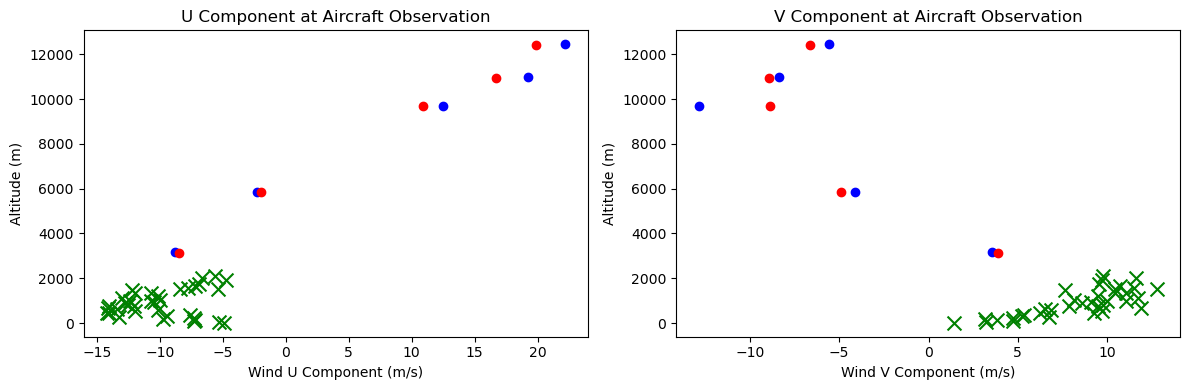

In [421]:
random_obs_1 = aircraft_df[(aircraft_df['4'] == 3) & (aircraft_df['26'] >= 0)].sample(n=1)

# sample all observations within the same hour and within deg degrees of lat and lon of the random observation
deg = 0.25
random_obs = aircraft_df[
    (aircraft_df['1'] == random_obs_1['1'].values[0]) & \
    (aircraft_df['2'] == random_obs_1['2'].values[0]) & \
    (aircraft_df['3'] == random_obs_1['3'].values[0]) & \
    (aircraft_df['4'] == random_obs_1['4'].values[0]) & \
    (aircraft_df['14'].between(random_obs_1['14'].values[0] - deg, random_obs_1['14'].values[0] + deg)) & \
    (aircraft_df['15'].between(random_obs_1['15'].values[0] - deg, random_obs_1['15'].values[0] + deg))
    ]

# select a random aircraft observation and plot the u and v components from the nearest era5 and ecmwf points across all pressure levels at the time and location of that observation
obs_lat = random_obs_1['14'].values[0]
obs_lon = random_obs_1['15'].values[0]
obs_year = random_obs_1['1'].values[0]
obs_month = random_obs_1['2'].values[0]
obs_day = random_obs_1['3'].values[0]
obs_hour = random_obs_1['4'].values[0]


# convert from -180 to 180 longitude to 0 to 360 longitude on the aircraft observation.
# do this by finding the minimum positive value of lon and lon + 360
obs_lon = obs_lon if obs_lon >= 0 else obs_lon + 360

# construct obs_time when each of the above is a float. They must be parsed to integers with the correct padding.
obs_time = f"{int(obs_year):04d}-{int(obs_month):02d}-{int(obs_day):02d}T{int(obs_hour):02d}:00:00.000000000"

# extract wind speed and direction
obs_windspeed = random_obs['26'].values # wind speed in m/s
obs_winddir = random_obs['25'].values # wind direction in degrees


obs_u = -obs_windspeed * np.sin(np.radians(obs_winddir))
obs_v = -obs_windspeed * np.cos(np.radians(obs_winddir))

obs_temp = random_obs['31'].values # temperature in K

# find the observation altitude in meters and convert to pressure in hPa using the barometric formula. Assume standard sea level pressure of 1013.25 hPa and a scale height of 8500 m.
obs_altitude = random_obs['16'].values # altitude in meters

# convert obs_time to numpy datetime64
obs_time = np.datetime64(obs_time)

era5_obs = era5_ds.sel(valid_time=obs_time, method='nearest').sel(latitude=obs_lat, longitude=obs_lon, method='nearest')[['u', 'v', 'z']]
ecmwf_obs = ecmwf_ds.sel(time=obs_time, method='nearest').sel(latitude=obs_lat, longitude=obs_lon, method='nearest')[['UGRD_200mb', 'VGRD_200mb', 'HGT_200mb',
                                                                                                                      'UGRD_250mb', 'VGRD_250mb', 'HGT_250mb',
                                                                                                                      'UGRD_300mb', 'VGRD_300mb', 'HGT_300mb',
                                                                                                                      'UGRD_500mb', 'VGRD_500mb', 'HGT_500mb',
                                                                                                                      'UGRD_700mb', 'VGRD_700mb', 'HGT_700mb']]

# two scatter plots of u and v components for era5 and ecmwf across pressure levels
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.title("U Component at Aircraft Observation")
plt.scatter(era5_obs['u'], era5_obs['z']/g, label='ERA5 U', color='blue')
plt.scatter(ecmwf_obs['UGRD_200mb'], ecmwf_obs['HGT_200mb'], label='ECMWF U 200mb', color='red')
plt.scatter(ecmwf_obs['UGRD_250mb'], ecmwf_obs['HGT_250mb'], label='ECMWF U 250mb', color='red')
plt.scatter(ecmwf_obs['UGRD_300mb'], ecmwf_obs['HGT_300mb'], label='ECMWF U 300mb', color='red')
plt.scatter(ecmwf_obs['UGRD_500mb'], ecmwf_obs['HGT_500mb'], label='ECMWF U 500mb', color='red')
plt.scatter(ecmwf_obs['UGRD_700mb'], ecmwf_obs['HGT_700mb'], label='ECMWF U 700mb', color='red')
plt.scatter(obs_u, obs_altitude, label='Aircraft U', color='green', marker='x', s=100)
plt.xlabel("Wind U Component (m/s)")
plt.ylabel("Altitude (m)")

plt.subplot(1, 2, 2)
plt.title("V Component at Aircraft Observation")
plt.scatter(era5_obs['v'], era5_obs['z']/g, label='ERA5 V', color='blue')
plt.scatter(ecmwf_obs['VGRD_200mb'], ecmwf_obs['HGT_200mb'], label='ECMWF V 200mb', color='red')
plt.scatter(ecmwf_obs['VGRD_250mb'], ecmwf_obs['HGT_250mb'], label='ECMWF V 250mb', color='red')
plt.scatter(ecmwf_obs['VGRD_300mb'], ecmwf_obs['HGT_300mb'], label='ECMWF V 300mb', color='red')
plt.scatter(ecmwf_obs['VGRD_500mb'], ecmwf_obs['HGT_500mb'], label='ECMWF V 500mb', color='red')
plt.scatter(ecmwf_obs['VGRD_700mb'], ecmwf_obs['HGT_700mb'], label='ECMWF V 700mb', color='red')
plt.scatter(obs_v, obs_altitude, label='Aircraft V', color='green', marker='x', s=100)
plt.xlabel("Wind V Component (m/s)")
plt.ylabel("Altitude (m)")

plt.tight_layout()

In [361]:
def uv_to_polar(u, v):
    speed = np.sqrt(u**2 + v**2)
    direction = np.arctan2(-u, -v)  # meteorological convention
    return direction, speed

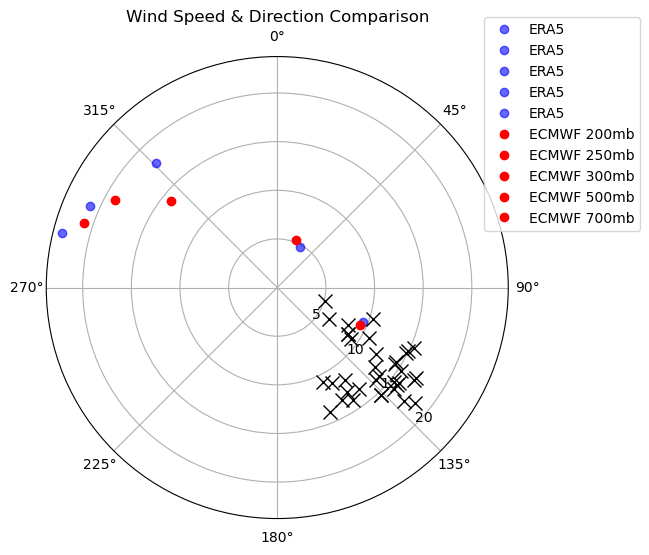

In [422]:
# compare the vectors by plotting the u and v components on a chart with u as the x-axis and v as the y-axis, with different colors for era5, ecmwf, and aircraft observations.
plt.figure(figsize=(6, 6))
ax = plt.subplot(111, polar=True)
plt.title("Wind Speed & Direction Comparison")

# ERA5
for u, v in zip(era5_obs['u'].values, era5_obs['v'].values):
    theta, r = uv_to_polar(u, v)
    ax.plot([theta], [r], 'o', label='ERA5', alpha=0.6, color='blue')

# ECMWF
for lvl in ['200mb','250mb','300mb','500mb','700mb']:
    u = ecmwf_obs[f'UGRD_{lvl}']
    v = ecmwf_obs[f'VGRD_{lvl}']
    theta, r = uv_to_polar(u, v)
    ax.plot([theta], [r], 'o', label=f'ECMWF {lvl}', color='red')

# Aircraft
theta, r = uv_to_polar(obs_u, obs_v)
ax.plot([theta], [r], 'x', markersize=10, color='black')

ax.set_theta_zero_location('N')   # 0° = North
ax.set_theta_direction(-1)        # clockwise
ax.set_rlabel_position(135)

plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

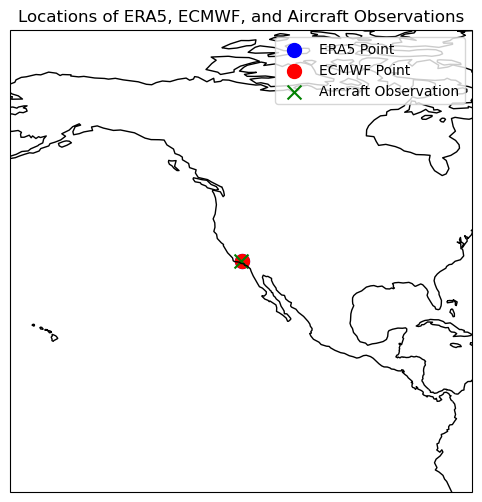

In [390]:
# plot the lat lon locations of the era5 and ecmwf points used in the comparison, along with the aircraft observation location on a map.
plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE)
ax.scatter(era5_obs.longitude, era5_obs.latitude, label='ERA5 Point', color='blue', marker='o', s=100, transform=ccrs.PlateCarree())
ax.scatter(ecmwf_obs.longitude, ecmwf_obs.latitude, label='ECMWF Point', color='red', marker='o', s=100, transform=ccrs.PlateCarree())
ax.scatter(obs_lon, obs_lat, label='Aircraft Observation', color='green', marker='x', s=100, transform=ccrs.PlateCarree())

# ensure the axes go +/- 20 degrees from the observation location
ax.set_extent([obs_lon - 45, obs_lon + 45, obs_lat - 45, obs_lat + 45], crs=ccrs.PlateCarree())

plt.legend()
plt.title('Locations of ERA5, ECMWF, and Aircraft Observations')
plt.show()

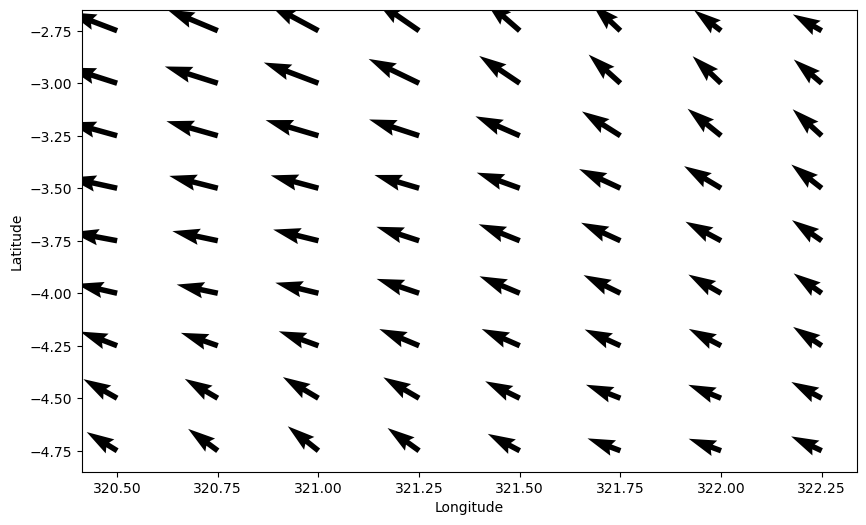

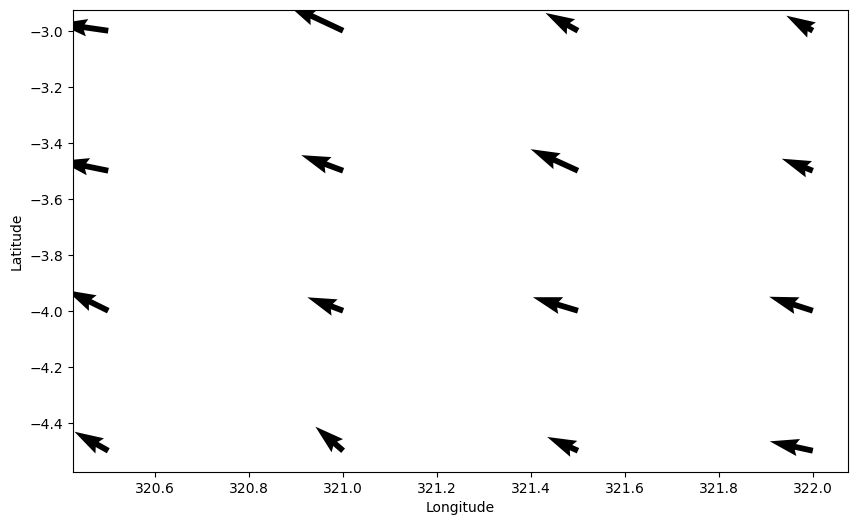

In [424]:
# plot quiver of the u and v components of the era5 grid surrounding the observation point at 200mb
upscale = 4
era5_obs_grid = era5_ds.sel(valid_time=obs_time, method='nearest').sel(latitude=slice(obs_lat + deg * upscale, obs_lat - deg * upscale), longitude=slice(obs_lon - deg * upscale, obs_lon + deg * upscale))[['u', 'v', 'z']]
ecmwf_obs_grid = ecmwf_ds.sel(time=obs_time, method='nearest').sel(latitude=slice(obs_lat - deg * upscale, obs_lat + deg * upscale), longitude=slice(obs_lon - deg * upscale, obs_lon + deg * upscale))[['UGRD_200mb', 'VGRD_200mb', 'HGT_200mb',
                                                                                                                      'UGRD_250mb', 'VGRD_250mb', 'HGT_250mb',
                                                                                                                      'UGRD_300mb', 'VGRD_300mb', 'HGT_300mb',
                                                                                                                      'UGRD_500mb', 'VGRD_500mb', 'HGT_500mb',
                                                                                                                      'UGRD_700mb', 'VGRD_700mb', 'HGT_700mb']]

plot1 = plot_quiver(
    era5_obs_grid.latitude.values,
    era5_obs_grid.longitude.values,
    era5_obs_grid.sel(pressure_level=700)['u'].values,
    era5_obs_grid.sel(pressure_level=700)['v'].values,
    reduce_factor=1
)

plot2 = plot_quiver(
    ecmwf_obs_grid.latitude.values,
    ecmwf_obs_grid.longitude.values,
    ecmwf_obs_grid['UGRD_700mb'].values,
    ecmwf_obs_grid['VGRD_700mb'].values,
    reduce_factor=1
)